<a href="https://colab.research.google.com/github/marcelozanchetta/EDS104/blob/main/Lab2_Atividade_Dados_Exploratorios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#### Importação e Análise dos dados
---

In [49]:
# importar as bibliotecas
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 


In [50]:

# fetch df 
credit_approval = fetch_ucirepo(id=27) 
  
# data (as pandas dataframes) 
X = credit_approval.data.features 
y = credit_approval.data.targets 
  
# metadata 
# print(credit_approval.metadata) 
  
# variable information 
# print(credit_approval.variables)

df = pd.concat([X, y], axis=1)
df.head()


,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
0,0,202.0,g,f,1,t,t,1.25,v,w,g,u,0.000,30.83,b,+
1,560,43.0,g,f,6,t,t,3.04,h,q,g,u,4.460,58.67,a,+
2,824,280.0,g,f,0,f,t,1.50,h,q,g,u,0.500,24.50,a,+
3,3,100.0,g,t,5,t,t,3.75,v,w,g,u,1.540,27.83,b,+
4,0,120.0,s,f,0,f,t,1.71,v,w,g,u,5.625,20.17,b,+


---
#### Questão 2) Use o df escolhido e mostre por meio das representações gráficas (histogramas) as principais características. Procure usar as funções apresentadas nesta atividade.
---

**Visualização dos atributos**

In [51]:
df.describe(include='all')

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
count,690.000000,677.000000,690,690,690.00000,690,690,690.000000,681,681,684,684,690.000000,678.000000,678,690
unique,NaN,NaN,3,2,NaN,2,2,NaN,9,14,3,3,NaN,NaN,2,2
top,NaN,NaN,g,f,NaN,f,t,NaN,v,c,g,u,NaN,NaN,b,-
freq,NaN,NaN,625,374,NaN,395,361,NaN,399,137,519,519,NaN,NaN,468,383
mean,1017.385507,184.014771,NaN,NaN,2.40000,NaN,NaN,2.223406,NaN,NaN,NaN,NaN,4.758725,31.568171,NaN,NaN
std,5210.102598,173.806768,NaN,NaN,4.86294,NaN,NaN,3.346513,NaN,NaN,NaN,NaN,4.978163,11.957862,NaN,NaN
min,0.000000,0.000000,NaN,NaN,0.00000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,13.750000,NaN,NaN
25%,0.000000,75.000000,NaN,NaN,0.00000,NaN,NaN,0.165000,NaN,NaN,NaN,NaN,1.000000,22.602500,NaN,NaN
50%,5.000000,160.000000,NaN,NaN,0.00000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.750000,28.460000,NaN,NaN
75%,395.500000,276.000000,NaN,NaN,3.00000,NaN,NaN,2.625000,NaN,NaN,NaN,NaN,7.207500,38.230000,NaN,NaN


**Histograma da classe**

Nossa coluna de destino será a coluna classe: A16, que assume valores positivos e negativos.
* Nota-se que o df se encontra desbalanceado, tendo mais representatividade de objetos com valores negativos

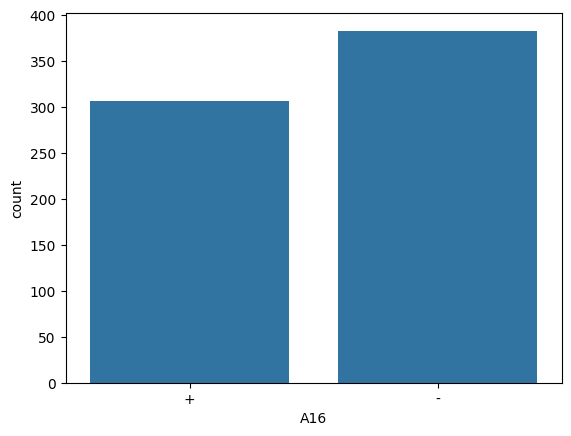

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='A16', data=df, )
plt.show()

**Distribuição dos dados para atributos contínuos**

* Nos atributos A15, A14 e A11 é provável que tenhamos a presença de outliers, considerando que a grande maioria dos dados se concentra num intervalo e os gráficos indicarem a presença de valores isolados muito distantes dessa concentração
* A8 e A11 têm concentração quase absoluta de seus dados em faixas estreitas, possivelmente categorizável
* A2 é o atributo com maior distribuição entre seus valores, em comparação aos demais

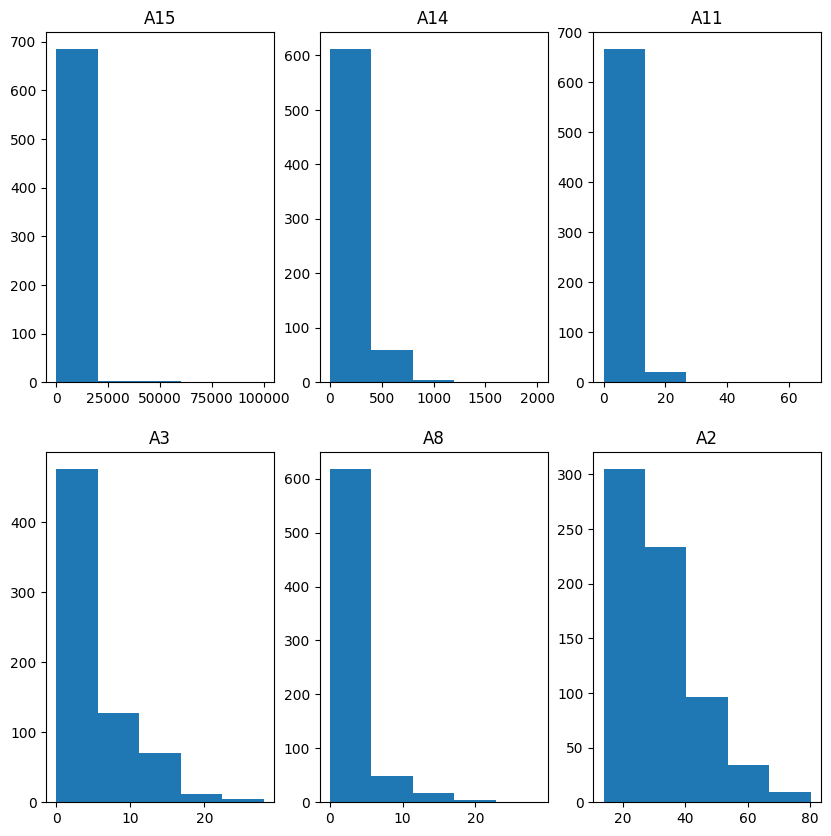

In [53]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10,10))

axes[0,0].set_title("A15")
axes[0,0].hist(df['A15'], bins=5)

axes[0,1].set_title("A14")
axes[0,1].hist(df['A14'], bins=5);

axes[0,2].set_title("A11")
axes[0,2].hist(df['A11'], bins=5);

axes[1,0].set_title("A3")
axes[1,0].hist(df['A3'], bins=5);

axes[1,1].set_title("A8")
axes[1,1].hist(df['A8'], bins=5);

axes[1,2].set_title("A2")
axes[1,2].hist(df['A2'], bins=5);



**Distribuição dos dados para atributos categóricos**

* Atributo A6 tem grande desbalanceamento entre valores, sendo a maioria 'c'
* Atributos A5 e A4 assumem dois valores mais representativos, e um terceiro mais incomum

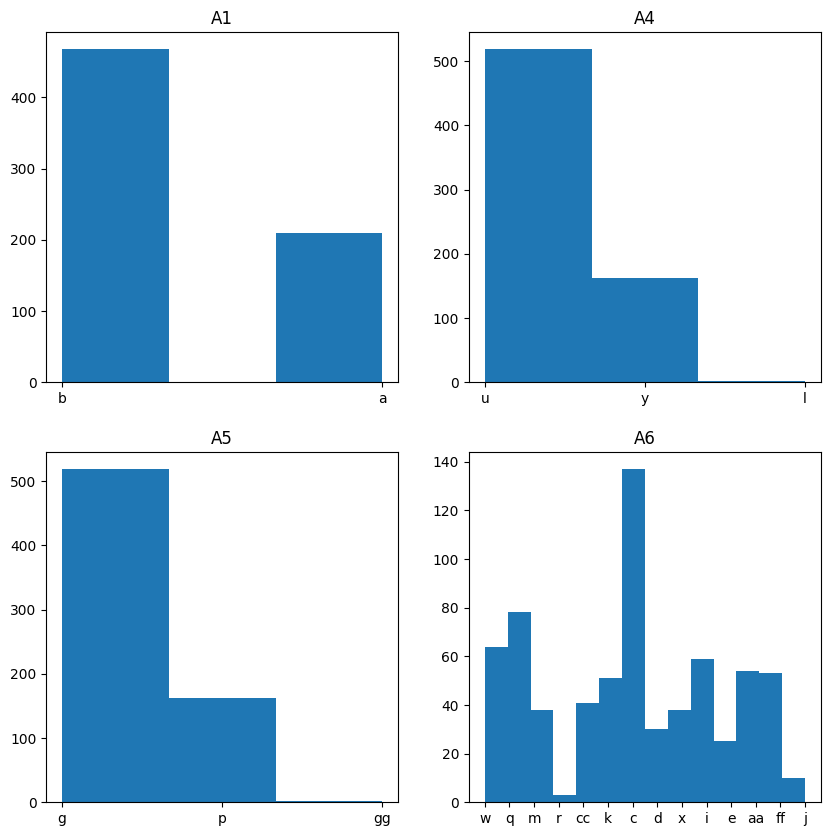

In [54]:

fig, ax = plt.subplots(2, 2, figsize=(10,10))

ax[0,0].set_title("A1")
ax[0,0].hist(df['A1'].dropna(), bins=3);

ax[0,1].set_title("A4")
ax[0,1].hist(df['A4'].dropna(), bins=3);

ax[1,0].set_title("A5")
ax[1,0].hist(df['A5'].dropna(), bins=3);

ax[1,1].set_title("A6")
ax[1,1].hist(df['A6'].dropna(), bins=14);


**A distribuição do atributo A2**

* O gráfico indica que a maioria das instância possuem valores baixos, enquanto a minoria representa valores mais altos
* A concentração dos dados se dá entre 20 e 30

<Axes: xlabel='A2', ylabel='Count'>

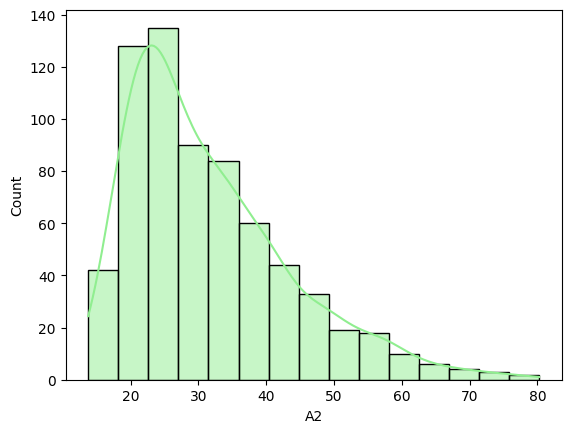

In [55]:
import seaborn as sns
sns.histplot(df['A2'], bins=15, kde=True, color='lightgreen')

---
#### Questão 3) O df Iris não possui valores ausentes. A base escolhida também pode conter todos os descritores por cada amostra. Use um df e sobre as amostras impute valores ausentes usando a média, mediana ou outras medidas.
---

In [56]:
df_notNull = df

# Encontra valores ausentes no dataframe
mv = df_notNull.isnull()
print(mv)

# Primeiro deve-se fazer o input dos valores numeric, pois se fizesse dos valores str
# iria perder os valores ausentes em colunas numeric, já que seriam preenchidos com a moda,
# e assim não teria como fazer o input dos numeric usando média

# Insere um valor onde há valores ausentes
df_notNull.fillna(df_notNull.mean(numeric_only=True), inplace=True) # usando média (valores numeric)
df_notNull.fillna(df_notNull.mode().iloc[0], inplace=True) # usando moda (valores str)

# Em df.mode().iloc[0] usou-se a função .iloc[0] para pegar o primeiro elemento
# retornado da função .mode() para casos em que haja mais de uma moda

# Verifica se há valores ausentes em alguma coluna
mv = df_notNull.isnull().sum()
print(mv)

       A15    A14    A13    A12    A11    A10     A9     A8     A7     A6  \
0    False  False  False  False  False  False  False  False  False  False   
1    False  False  False  False  False  False  False  False  False  False   
2    False  False  False  False  False  False  False  False  False  False   
3    False  False  False  False  False  False  False  False  False  False   
4    False  False  False  False  False  False  False  False  False  False   
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
685  False  False  False  False  False  False  False  False  False  False   
686  False  False  False  False  False  False  False  False  False  False   
687  False  False  False  False  False  False  False  False  False  False   
688  False  False  False  False  False  False  False  False  False  False   
689  False  False  False  False  False  False  False  False  False  False   

        A5     A4     A3     A2     A1    A16  
0    False  False  False  F

---
#### Questão 4) Após aplicação das operações, faça a representação gráfica com histogramas das novas características dos dados analisados.
---

**Distribuição dos dados para atributos contínuos - valores nulos preenchidos**

* Houveram mudanças no gráfico de A2 com um aumento da frequência no intervalo entre 20 e 40, o que condiz com o valor médio do atributo (~31,5)
* Também é notável uma diferença no gráfico de A14, que agora ultrapassa a frequência de 600 no intervalo entre 0 e 500, tendo sido preenchido com mais valores médios desse atributo (~184)

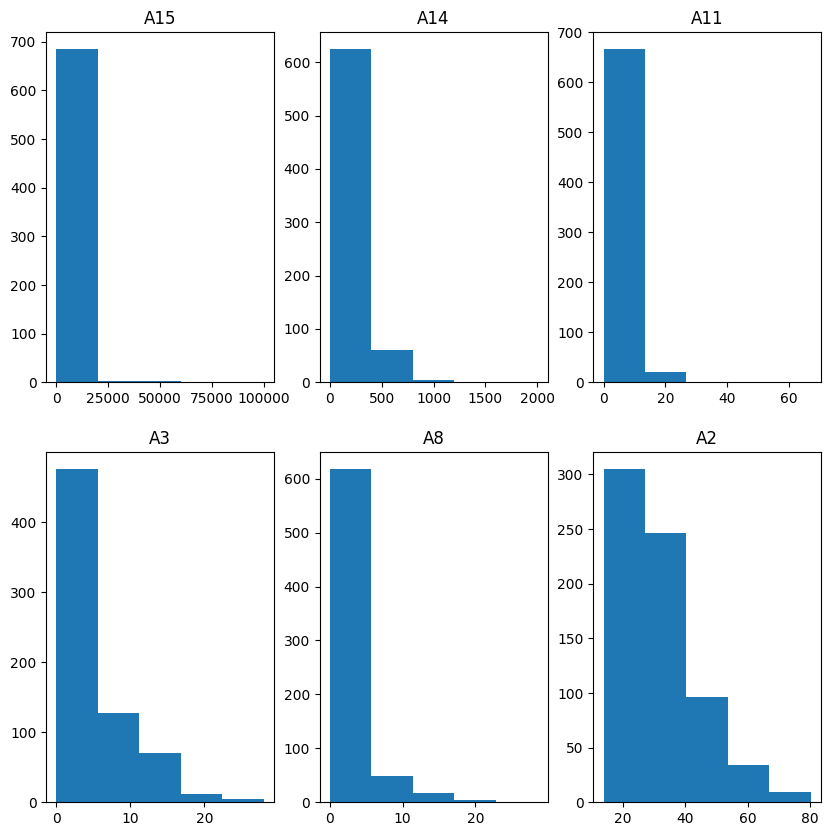

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(10,10))

axes[0,0].set_title("A15")
axes[0,0].hist(df_notNull['A15'], bins=5)

axes[0,1].set_title("A14")
axes[0,1].hist(df_notNull['A14'], bins=5);

axes[0,2].set_title("A11")
axes[0,2].hist(df_notNull['A11'], bins=5);

axes[1,0].set_title("A3")
axes[1,0].hist(df_notNull['A3'], bins=5);

axes[1,1].set_title("A8")
axes[1,1].hist(df_notNull['A8'], bins=5);

axes[1,2].set_title("A2")
axes[1,2].hist(df_notNull['A2'], bins=5);


**Distribuição dos dados para atributos categóricos - valores nulos preenchidos**

* Nota-se que todos os gráficos mudaram em sua contagem de frequências: 
    - A1 aumentou frequência em 'b'
    - A4 aumentou frequência em 'u'
    - A5 em 'g'
    - e A6 aumentou em 'c'

Mantendo todas as demais classes igualmente representadas

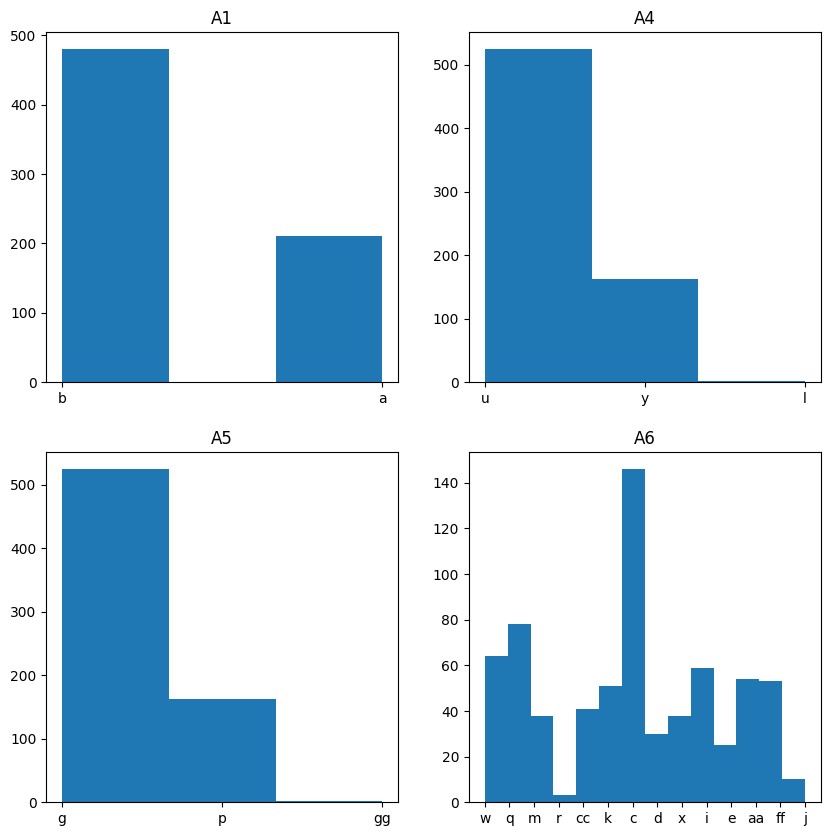

In [58]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

ax[0,0].set_title("A1")
ax[0,0].hist(df_notNull['A1'], bins=3);

ax[0,1].set_title("A4")
ax[0,1].hist(df_notNull['A4'], bins=3);

ax[1,0].set_title("A5")
ax[1,0].hist(df_notNull['A5'], bins=3);

ax[1,1].set_title("A6")
ax[1,1].hist(df_notNull['A6'], bins=14);

**A distribuição do atributo A6 - valores nulos preenchidos**

Houve um aumento na frequência dos valores entre 30 e 35, antes menor que a coluna à esquerda, que contribuiu na mudança da curva de densidade

<Axes: xlabel='A2', ylabel='Count'>

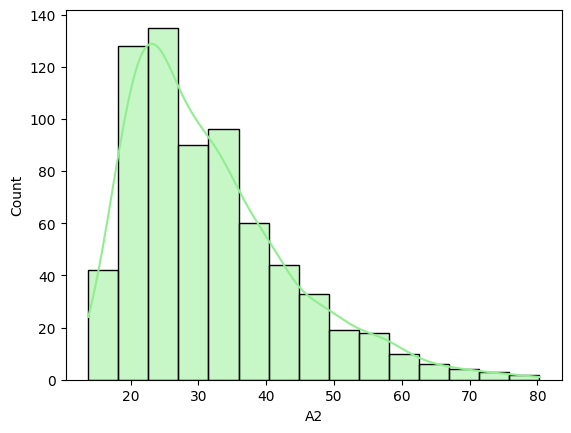

In [59]:
sns.histplot(df_notNull['A2'], bins=15, kde=True, color='lightgreen')

---
#### Questão 5) Compare os resultados obtidos usando um gráfico box plot. Que atributos possuem distribuições mais simétricas? Há a presença de valores extremos, denominados de outliers, para os atributos?
---

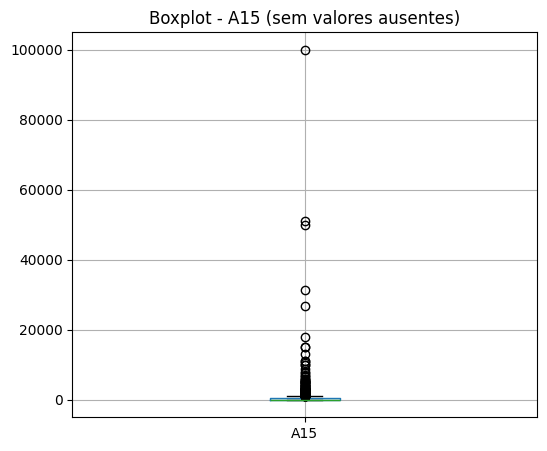

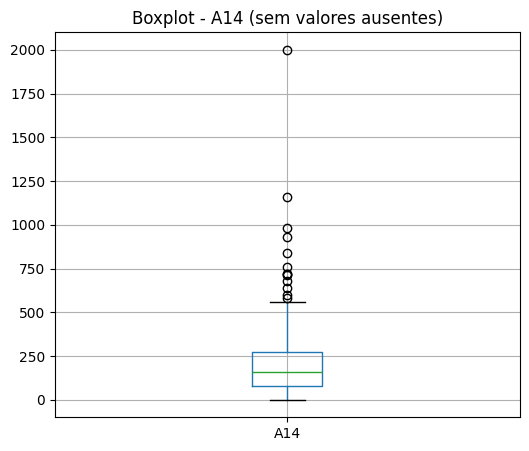

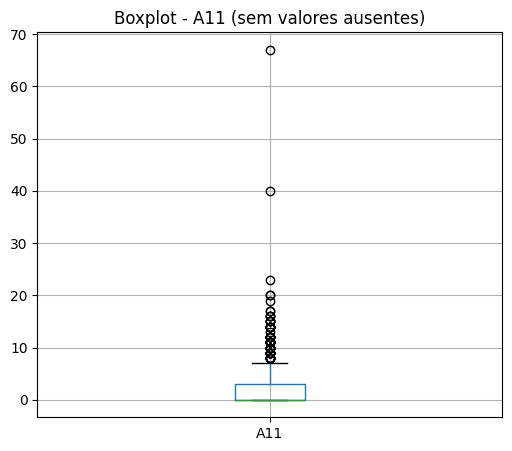

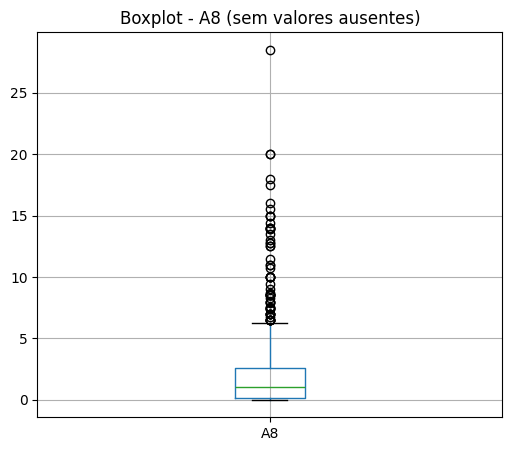

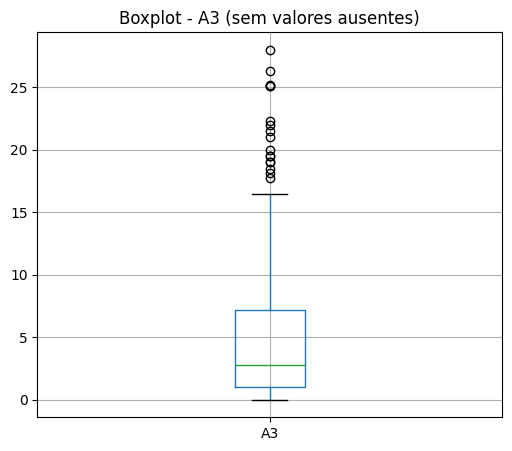

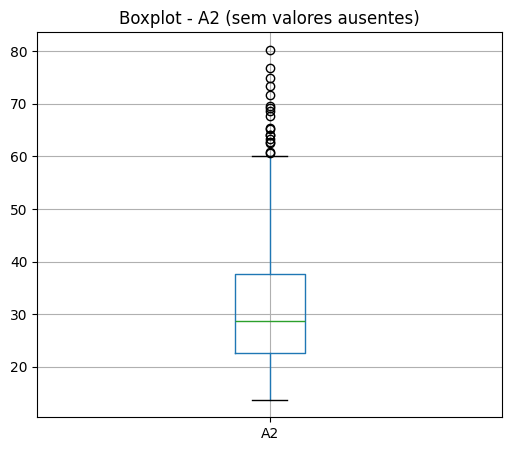

In [60]:
import matplotlib.pyplot as plt

for col in df_notNull.select_dtypes(include='number').columns:
    df_notNull.boxplot(column=col, figsize=(6,5))
    plt.title(f"Boxplot - {col} (sem valores ausentes)")
    plt.grid(True)
    plt.show()

Ao analisar os boxplots do dataframe sem valores ausentes, é possível ver que todas as variáveis numéricas apresentam valores extremos (outliers). A variável A15 é a que mais se destaca, pois tem valores muito maiores do que as outras, o que faz com que apareçam muitos pontos fora da caixa do boxplot.

As variáveis A14, A11, A8, A3 e A2 também têm outliers, mas em menor quantidade e com valores bem menores quando comparado com A15.

Sobre a simetria, nenhuma das variáveis é totalmente simétrica. Porém, as variáveis A3 e A2 estão mais próximas de uma distribuição “mais equilibrada” em torno da mediana, enquanto A15 e A14 são mais distorcidas por causa dos valores extremos.

---
#### Questão 6) No df escolhido selecione intervalos de amostragem (10%, 30% e 50% - Progressiva) e faça análises sobre os dados em relação as métricas estatísticas. O que você pode observar sobre os subconjuntos em relação as métricas estatísticas com a nova composição dos dados?
---

In [61]:
# Amostra de 10% dos dados
amostra_10_p = df.sample(frac=0.1, random_state=42) # random_state garante reprodutibilidade

# Amostra de 30% dos dados
amostra_30_p = df.sample(frac=0.3, random_state=42)

# Amostra de 50% dos dados
amostra_50_p = df.sample(frac=0.5, random_state=42)


**Descrição do dataset completo**

In [62]:
df.describe(include="all")

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
count,690.000000,690.000000,690,690,690.00000,690,690,690.000000,690,690,690,690,690.000000,690.000000,690,690
unique,NaN,NaN,3,2,NaN,2,2,NaN,9,14,3,3,NaN,NaN,2,2
top,NaN,NaN,g,f,NaN,f,t,NaN,v,c,g,u,NaN,NaN,b,-
freq,NaN,NaN,625,374,NaN,395,361,NaN,408,146,525,525,NaN,NaN,480,383
mean,1017.385507,184.014771,NaN,NaN,2.40000,NaN,NaN,2.223406,NaN,NaN,NaN,NaN,4.758725,31.568171,NaN,NaN
std,5210.102598,172.159274,NaN,NaN,4.86294,NaN,NaN,3.346513,NaN,NaN,NaN,NaN,4.978163,11.853273,NaN,NaN
min,0.000000,0.000000,NaN,NaN,0.00000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,13.750000,NaN,NaN
25%,0.000000,80.000000,NaN,NaN,0.00000,NaN,NaN,0.165000,NaN,NaN,NaN,NaN,1.000000,22.670000,NaN,NaN
50%,5.000000,160.000000,NaN,NaN,0.00000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.750000,28.625000,NaN,NaN
75%,395.500000,272.000000,NaN,NaN,3.00000,NaN,NaN,2.625000,NaN,NaN,NaN,NaN,7.207500,37.707500,NaN,NaN


**Descrição 10% do dataset**

In [63]:
amostra_10_p.describe(include="all")

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
count,69.000000,69.00000,69,69,69.000000,69,69,69.000000,69,69,69,69,69.000000,69.000000,69,69
unique,NaN,NaN,2,2,NaN,2,2,NaN,6,13,2,2,NaN,NaN,2,2
top,NaN,NaN,g,t,NaN,f,t,NaN,v,c,g,u,NaN,NaN,b,-
freq,NaN,NaN,60,36,NaN,43,36,NaN,38,15,53,53,NaN,NaN,48,36
mean,1057.927536,207.73913,NaN,NaN,2.101449,NaN,NaN,2.768696,NaN,NaN,NaN,NaN,4.700290,30.923425,NaN,NaN
std,6151.825612,230.26881,NaN,NaN,3.730419,NaN,NaN,4.564619,NaN,NaN,NaN,NaN,5.057529,11.615639,NaN,NaN
min,0.000000,0.00000,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,15.750000,NaN,NaN
25%,0.000000,32.00000,NaN,NaN,0.000000,NaN,NaN,0.165000,NaN,NaN,NaN,NaN,0.750000,21.750000,NaN,NaN
50%,1.000000,160.00000,NaN,NaN,0.000000,NaN,NaN,0.875000,NaN,NaN,NaN,NaN,2.500000,29.830000,NaN,NaN
75%,300.000000,280.00000,NaN,NaN,3.000000,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,7.000000,38.670000,NaN,NaN


**Descrição 30% do dataset**

In [64]:
amostra_30_p.describe(include="all")

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
count,207.000000,207.000000,207,207,207.000000,207,207,207.000000,207,207,207,207,207.000000,207.000000,207,207
unique,NaN,NaN,3,2,NaN,2,2,NaN,7,14,3,3,NaN,NaN,2,2
top,NaN,NaN,g,f,NaN,f,t,NaN,v,c,g,u,NaN,NaN,b,-
freq,NaN,NaN,183,112,NaN,123,114,NaN,125,41,164,164,NaN,NaN,144,110
mean,1120.932367,195.898622,NaN,NaN,2.280193,NaN,NaN,2.691304,NaN,NaN,NaN,NaN,4.865242,31.792701,NaN,NaN
std,5535.326304,187.263515,NaN,NaN,4.532380,NaN,NaN,4.076161,NaN,NaN,NaN,NaN,5.178378,11.962315,NaN,NaN
min,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,15.170000,NaN,NaN
25%,0.000000,74.000000,NaN,NaN,0.000000,NaN,NaN,0.165000,NaN,NaN,NaN,NaN,0.937500,22.625000,NaN,NaN
50%,0.000000,160.000000,NaN,NaN,0.000000,NaN,NaN,1.250000,NaN,NaN,NaN,NaN,2.500000,29.830000,NaN,NaN
75%,353.500000,280.000000,NaN,NaN,3.000000,NaN,NaN,3.500000,NaN,NaN,NaN,NaN,7.375000,38.960000,NaN,NaN


**Descrição 50% do dataset**

In [65]:
amostra_50_p.describe(include="all")

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
count,345.000000,345.000000,345,345,345.000000,345,345,345.000000,345,345,345,345,345.000000,345.000000,345,345
unique,NaN,NaN,3,2,NaN,2,2,NaN,8,14,3,3,NaN,NaN,2,2
top,NaN,NaN,g,f,NaN,f,t,NaN,v,c,g,u,NaN,NaN,b,-
freq,NaN,NaN,313,180,NaN,203,184,NaN,203,77,264,264,NaN,NaN,238,191
mean,977.113043,186.539259,NaN,NaN,2.321739,NaN,NaN,2.499043,NaN,NaN,NaN,NaN,4.780333,31.729987,NaN,NaN
std,4496.011418,171.122028,NaN,NaN,4.417620,NaN,NaN,3.745885,NaN,NaN,NaN,NaN,5.189488,11.890300,NaN,NaN
min,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,15.170000,NaN,NaN
25%,0.000000,70.000000,NaN,NaN,0.000000,NaN,NaN,0.250000,NaN,NaN,NaN,NaN,1.000000,22.500000,NaN,NaN
50%,1.000000,160.000000,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.500000,29.580000,NaN,NaN
75%,350.000000,276.000000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,7.250000,38.750000,NaN,NaN


Pela comparação das métricas estatísticas entre o data frame completo e suas amostras, vê-se que:
* Alguns valores deixam de ser representados (quantidade variável de unique em atributos categóricos)
* Os valores mínimos e máximos das amostras de 30% e 50% se mantiveram as mesmas
* Não há grande discrepância quanto ao nível de desbalanceamento da classe, todos mantêm uma proporção próxima a 53%
* Não houve diferença tão significativa quanto aos 75% dos valores nos atributos contínuos